# Load the dataset

In [126]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


In [127]:
import pandas as pd
import os

In [128]:
print(path)

/kaggle/input/telco-customer-churn


In [129]:
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [130]:
file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [131]:
file_path

'/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [132]:
df = pd.read_csv(file_path)

In [133]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

In [134]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [135]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [136]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [137]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [138]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [139]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [140]:
print(df["TotalCharges"].dtype)

float64


In [141]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [142]:
# Plot some graphs

In [143]:
import matplotlib.pyplot as plt


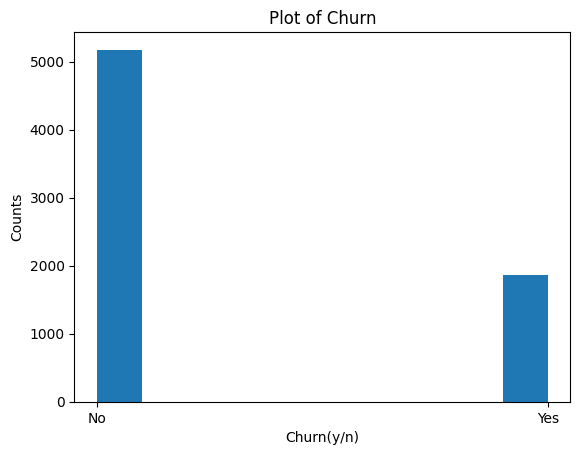

In [144]:
plt.hist(df["Churn"])
plt.ylabel("Counts")
plt.xlabel("Churn(y/n)")
plt.title("Plot of Churn")
plt.show()

In [145]:
df["tenure"]

,tenure
0,1
1,34
2,2
3,45
4,2
...,...
7038,24
7039,72
7040,11
7041,4


In [146]:
def tenure_time(x):

  if x < 12:
    return "0-1 year"
  elif x < 24:
    return "1-2 years"
  elif x < 48:
    return "2-4 years"
  else:
    return "4+ years"

df["tenure"] = df["tenure"].apply(tenure_time)

In [147]:
df["tenure"]

,tenure
0,0-1 year
1,2-4 years
2,0-1 year
3,2-4 years
4,0-1 year
...,...
7038,2-4 years
7039,4+ years
7040,0-1 year
7041,0-1 year


(array([2069.,    0.,    0., 1624.,    0.,    0., 1047.,    0.,    0.,
        2303.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

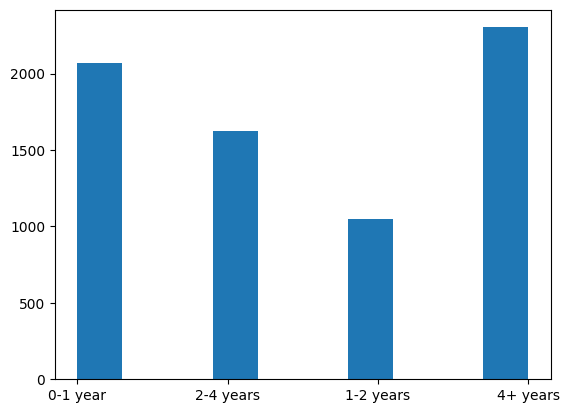

In [148]:
plt.hist(df["tenure"])

In [149]:
# Binary encode the target variable

In [150]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [151]:
print(df["Churn"].value_counts)

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64>


In [152]:
print(df["Churn"].value_counts(normalize=True))

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [153]:
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)

In [154]:
contract_churn

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [155]:
pd.crosstab(df["Contract"],df["Churn"])

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [156]:
internet_churn = df.groupby("InternetService")["Churn"].mean().sort_values(ascending = False)

In [157]:
internet_churn

,Churn
InternetService,
Fiber optic,0.418928
DSL,0.189591
No,0.074050


In [158]:
pd.crosstab(df["InternetService"],df["Churn"])

Churn,0,1
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [159]:
# Monthly Charges

In [160]:
df["monthly_Charges_group"] = pd.cut(df["MonthlyCharges"],bins=[0,35,70,100,150],labels = ("Low", "Medium", "High", "Very High"))

In [161]:
df["monthly_Charges_group"]

,monthly_Charges_group
0,Low
1,Medium
2,Medium
3,Medium
4,High
...,...
7038,High
7039,Very High
7040,Low
7041,High


In [162]:
pd.crosstab(df['monthly_Charges_group'],df['Churn'],normalize='index')

Churn,0,1
monthly_Charges_group,,
Low,0.891066,0.108934
Medium,0.760580,0.239420
High,0.621783,0.378217
Very High,0.719512,0.280488


In [163]:
monthly_charges_churn = df.groupby('monthly_Charges_group')['Churn'].mean().sort_values(ascending=False)

/tmp/ipykernel_1641/3305585440.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_charges_churn = df.groupby('monthly_Charges_group')['Churn'].mean().sort_values(ascending=False)


In [164]:
# Visualizations

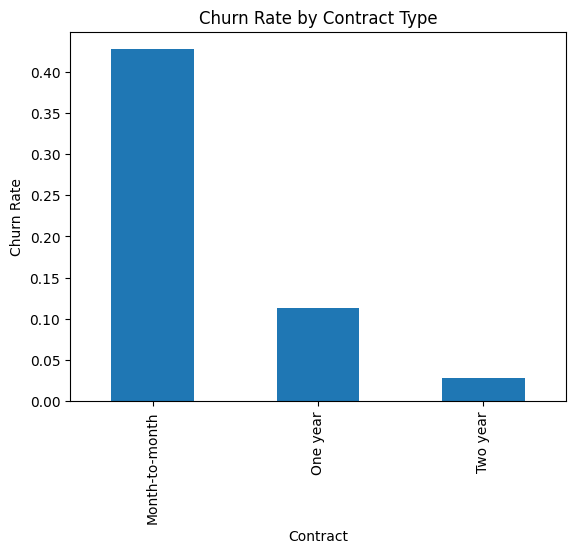

In [165]:
contract_churn.plot(kind="bar")

plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")

plt.show()

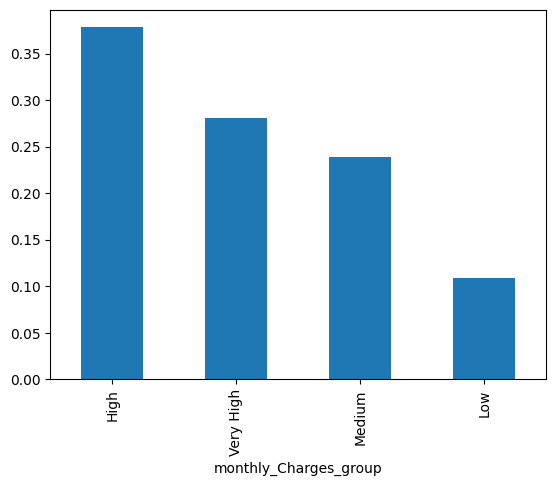

In [166]:
monthly_charges_churn.plot(kind = "bar")
plt.show()

In [167]:
# Model Building

In [168]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score,root_mean_squared_error,accuracy_score
from sklearn.preprocessing import StandardScaler

In [169]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'monthly_Charges_group'],
      dtype='object')

In [170]:
X = df.drop(["customerID", "Churn", "monthly_Charges_group"], axis=1)

In [171]:
X = pd.get_dummies(X, drop_first=True)

In [172]:
y = df["Churn"]

In [173]:
X = X.dropna()
y = y[X.index]

In [174]:
scaler = StandardScaler()

In [175]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.26,random_state=42)

In [176]:
X_train.size

166496

In [177]:
X_test.size

58528

In [178]:
y_train.size

5203

In [179]:
y_test.size

1829

In [180]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [181]:
model = LogisticRegression(max_iter=100, class_weight="balanced")

In [182]:
model.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced')

In [183]:
preds = model.predict(X_test_scaled)

In [184]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1352
           1       0.50      0.79      0.61       477

    accuracy                           0.74      1829
   macro avg       0.70      0.76      0.71      1829
weighted avg       0.80      0.74      0.76      1829



In [185]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [186]:
preds_rf = rf.predict(X_test_scaled)

In [187]:
print(classification_report(y_test, preds_rf))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1352
           1       0.53      0.71      0.61       477

    accuracy                           0.76      1829
   macro avg       0.71      0.74      0.72      1829
weighted avg       0.79      0.76      0.77      1829

